# 베이지안 신경망을 이용한 임금–연령 프로파일의 비선형 추정과 불확실성 정량화

**베이지안 기계학습 기말 보고서 — 분석 노트북**

---

## 0. 요약 (Abstract)

전통적 신경망(NN)은 최대가능도(MLE)로 가중치를 **단일 값**으로 추정하여 예측의
**불확실성을 표현하지 못한다.** 본 분석은 미국 임금 데이터(ISLR `Wage`, n=3,000)의
대표적 비선형 관계인 **연령–임금 프로파일(역U자 곡선)** 을 대상으로,

1. 다항회귀(빈도주의, 점추정),
2. 일반 신경망(MLE, 점추정),
3. **베이지안 신경망(BNN)** — 가중치를 확률분포로 두고 변분추론(SVI)으로 사후분포 근사

세 모형을 비교한다. 핵심 메시지는 BNN이 **데이터가 희박한 구간(청년·고령)에서
불확실성(신용구간)을 스스로 넓힌다**는 점이며, 이는 "모르는 곳에서 모른다고 말하는"
베이지안 추론의 본질을 보여준다. 추가로 NUTS(HMC) 샘플링으로 SVI 근사를 검증하고,
사전분포(prior)의 수축 강도에 따른 민감도를 분석한다.


## 1. 서론

### 1.1 왜 베이지안 신경망인가
신경망은 임의의 매끄러운 함수를 근사할 수 있는 강력한 도구이나(universal approximator),
표준적인 학습은 손실을 최소화하는 **하나의 가중치 집합**만을 찾는다(MLE). 이때 데이터를
똑같이 잘 설명하는 다른 가중치 조합의 가능성은 버려지며, 그 결과 **예측의 신뢰도**를
정량화할 수 없다. 베이지안 신경망(BNN)은 가중치 $w$ 에 사전분포 $p(w)$ 를 부여하고
사후분포 $p(w\mid \mathcal{D})$ 를 추론하여, 베이지안 모델 평균(BMA)을 통한 예측과
**불확실성의 정량화**를 동시에 달성한다(12강).

### 1.2 분석 대상: 연령–임금의 비선형성
노동경제학에서 임금은 연령(경력)에 따라 상승하다가 정점 후 완만해지는 **역U자(concave)**
프로파일을 보인다. 선형모형으로는 포착할 수 없는 이 비선형 구조는 신경망이 자동으로
학습하기에 적합하다. 또한 표본은 중년층에 집중되고 청년·고령층은 희박하므로,
**불확실성이 연령 구간에 따라 어떻게 달라지는지**를 보여주기에 이상적인 사례다.


## 2. 환경 및 데이터

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive, MCMC, NUTS
from numpyro.infer.autoguide import AutoNormal
import numpyro.diagnostics as diag

import torch
import torch.nn as nn

numpyro.set_host_device_count(1)
RNG = np.random.default_rng(0)
torch.manual_seed(0)
plt.rcParams["figure.dpi"] = 110
print("jax", jax.__version__, "| numpyro", numpyro.__version__, "| torch", torch.__version__)

D:\python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


jax 0.10.0 | numpyro 0.21.0 | torch 2.12.0+cpu


In [2]:
df = pd.read_csv("Wage.csv")
print("shape:", df.shape)
df[["year", "age", "education", "wage"]].head()

shape: (3000, 12)


,year,age,education,wage
0,2006,18,1. < HS Grad,75.043154
1,2004,24,4. College Grad,70.476020
2,2003,45,3. Some College,130.982177
3,2003,43,4. College Grad,154.685293
4,2005,50,2. HS Grad,75.043154


### 2.1 탐색적 자료 분석 (EDA)

연령대별 평균임금을 보면 18세 부근에서 가장 낮고 40대 중반에서 정점을 찍은 뒤
완만하게 감소하는 전형적인 역U자 패턴이 나타난다. 동시에 표본 수(count)는 중년층에
집중되어 있어 양 끝(청년·고령)은 데이터가 희박하다.

In [3]:
age = df["age"].to_numpy(float)
wage = df["wage"].to_numpy(float)

df["agebin"] = pd.cut(df["age"], bins=[17,25,30,35,40,45,50,55,60,80])
tbl = df.groupby("agebin", observed=True)["wage"].agg(["mean", "count"])
print(tbl.round(1))

           mean  count
agebin                
(17, 25]   76.3    231
(25, 30]  100.1    291
(30, 35]  107.3    379
(35, 40]  118.7    428
(40, 45]  119.4    466
(45, 50]  117.7    449
(50, 55]  117.5    346
(55, 60]  119.1    237
(60, 80]  112.8    173


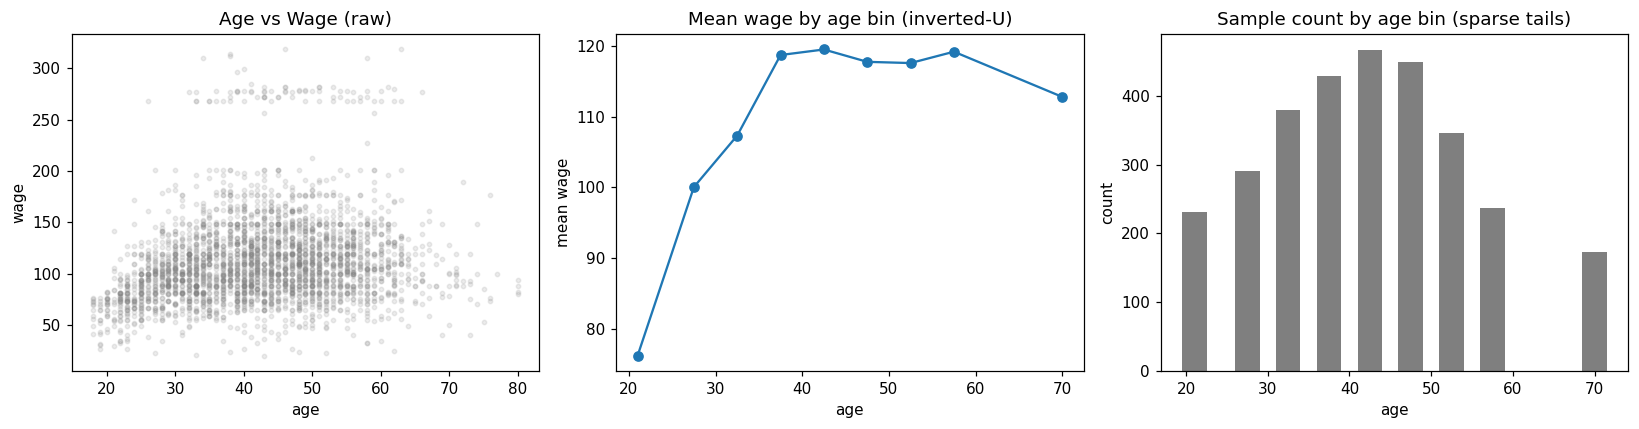

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].scatter(age, wage, s=8, alpha=0.15, color="gray")
ax[0].set_title("Age vs Wage (raw)"); ax[0].set_xlabel("age"); ax[0].set_ylabel("wage")

centers = [21,27.5,32.5,37.5,42.5,47.5,52.5,57.5,70]
ax[1].plot(centers, tbl["mean"].values, "o-", color="tab:blue")
ax[1].set_title("Mean wage by age bin (inverted-U)")
ax[1].set_xlabel("age"); ax[1].set_ylabel("mean wage")

ax[2].bar(centers, tbl["count"].values, width=3, color="tab:gray")
ax[2].set_title("Sample count by age bin (sparse tails)")
ax[2].set_xlabel("age"); ax[2].set_ylabel("count")
plt.tight_layout(); plt.savefig("fig_eda.png", bbox_inches="tight"); plt.show()

임금 분포에는 100~150 부근의 주된 군집 외에 250 이상의 **고소득 군집**이 별도로
존재하는 이봉(bimodal) 구조가 있다. 이는 연령 단독으로는 설명되지 않는 이질성으로,
뒤의 논의에서 단일 정규 가능도의 한계로 다룬다.

In [5]:
# 표준화 + 학습/검증 분할(80/20)
age_m, age_s = age.mean(), age.std()
wage_m, wage_s = wage.mean(), wage.std()
xz = (age - age_m) / age_s
yz = (wage - wage_m) / wage_s

n = len(df); idx = RNG.permutation(n); n_tr = int(0.8 * n)
tr, te = idx[:n_tr], idx[n_tr:]
x_tr, y_tr = xz[tr], yz[tr]
x_te, y_te = xz[te], yz[te]

age_grid = np.linspace(age.min(), age.max(), 200)
xg = (age_grid - age_m) / age_s
unz_y = lambda z: z * wage_s + wage_m   # 표준화 역변환
print(f"train={len(tr)}  test={len(te)}")

train=2400  test=600


## 3. 방법론

### 3.1 베이지안 신경망 모형
입력 $x$(표준화된 연령)에 대해 은닉층 1개(유닛 $H=16$, tanh)를 가진 신경망
$f_w(x)$ 를 두고, 임금을 다음과 같이 모형화한다.

$$ y_i \mid w,\sigma \sim \mathcal{N}\!\big(f_w(x_i),\, \sigma^2\big), \qquad
   f_w(x)= w_2^\top \tanh(w_1 x + b_1) + b_2. $$

가중치·절편에는 가우시안 사전분포 $w \sim \mathcal{N}(0,\, s^2)$ 를, 잡음 표준편차에는
$\sigma \sim \text{HalfNormal}(1)$ 을 부여한다. 사전 표준편차 $s$ 는 가중치를 0으로
당기는 **수축(shrinkage)** 강도를 조절하며(12강 4절), §5.2에서 민감도를 분석한다.

### 3.2 변분추론(SVI)과 ELBO
사후분포 $p(w,\sigma\mid\mathcal D)$ 는 직접 계산이 불가능하므로, 다루기 쉬운 변분분포
$q_\lambda$(대각 정규근사, mean-field)로 근사하고 **증거하한(ELBO)** 을 최대화한다(9·12강).
ELBO는 단조 증가하며 수렴 진단의 지표가 된다. 본 노트북은 SVI를 주 추론기로 쓰고,
NUTS(HMC) 샘플링으로 그 근사 품질을 교차검증한다.

## 4. 모형 적합

### 4.1 다항회귀 (빈도주의, 점추정)
ISLR에서 연령–임금에 표준적으로 쓰이는 4차 다항회귀를 OLS로 적합하고,
평균함수의 95% 신뢰구간을 함께 구한다.

In [6]:
def poly_design(x, deg):
    return np.vstack([x ** k for k in range(deg + 1)]).T

deg = 4
Xtr = poly_design(x_tr, deg)
beta, *_ = np.linalg.lstsq(Xtr, y_tr, rcond=None)
resid = y_tr - Xtr @ beta
sigma2 = (resid @ resid) / (len(y_tr) - (deg + 1))
XtX_inv = np.linalg.inv(Xtr.T @ Xtr)

Xg = poly_design(xg, deg)
poly_mean = unz_y(Xg @ beta)
poly_se = np.sqrt(np.einsum("ij,jk,ik->i", Xg, XtX_inv * sigma2, Xg)) * wage_s
poly_lo, poly_hi = poly_mean - 1.96 * poly_se, poly_mean + 1.96 * poly_se

poly_rmse = np.sqrt(np.mean((unz_y(poly_design(x_te, deg) @ beta) - unz_y(y_te)) ** 2))
print(f"[Poly deg-4] test RMSE = {poly_rmse:.2f}")

[Poly deg-4] test RMSE = 39.98


### 4.2 일반 신경망 (MLE, 점추정)
BNN과 동일한 구조(은닉 16×2, tanh)를 PyTorch로 두고 MSE를 Adam으로 최소화한다.
가중치는 단일 값으로 추정되어 예측에 불확실성이 없다.

In [7]:
net = nn.Sequential(nn.Linear(1,16), nn.Tanh(),
                    nn.Linear(16,16), nn.Tanh(), nn.Linear(16,1))
opt = torch.optim.Adam(net.parameters(), lr=1e-2)
lossf = nn.MSELoss()
Xtr_t = torch.tensor(x_tr, dtype=torch.float32).unsqueeze(1)
ytr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
for ep in range(3000):
    opt.zero_grad(); loss = lossf(net(Xtr_t), ytr_t); loss.backward(); opt.step()
net.eval()
with torch.no_grad():
    nn_grid = unz_y(net(torch.tensor(xg, dtype=torch.float32).unsqueeze(1)).squeeze(1).numpy())
    nn_te = net(torch.tensor(x_te, dtype=torch.float32).unsqueeze(1)).squeeze(1).numpy()
nn_rmse = np.sqrt(np.mean((unz_y(nn_te) - unz_y(y_te)) ** 2))
print(f"[NN MLE] test RMSE = {nn_rmse:.2f}")

[NN MLE] test RMSE = 40.32


### 4.3 베이지안 신경망 (SVI)

In [8]:
def bnn(x, y=None, H=16, prior_sd=1.0):
    x = x[:, None]; N, D = x.shape
    w1 = numpyro.sample("w1", dist.Normal(jnp.zeros((D, H)), prior_sd).to_event(2))
    b1 = numpyro.sample("b1", dist.Normal(jnp.zeros(H), prior_sd).to_event(1))
    z1 = jnp.tanh(x @ w1 + b1)
    w2 = numpyro.sample("w2", dist.Normal(jnp.zeros((H, 1)), prior_sd).to_event(2))
    b2 = numpyro.sample("b2", dist.Normal(0.0, prior_sd))
    mu = (z1 @ w2 + b2).squeeze(-1)
    numpyro.deterministic("mu", mu)
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    with numpyro.plate("data", N):
        numpyro.sample("y", dist.Normal(mu, sigma), obs=y)

def fit_svi(prior_sd, steps=20000, seed=0):
    guide = AutoNormal(bnn)
    svi = SVI(bnn, guide, numpyro.optim.Adam(5e-3), Trace_ELBO())
    res = svi.run(jax.random.PRNGKey(seed), steps,
                  jnp.array(x_tr), jnp.array(y_tr), prior_sd=prior_sd, progress_bar=False)
    return guide, res

guide, res = fit_svi(prior_sd=1.0)
print(f"ELBO: start={float(res.losses[0]):.0f}  end={float(res.losses[-1]):.0f}")

ELBO: start=139502  end=3382


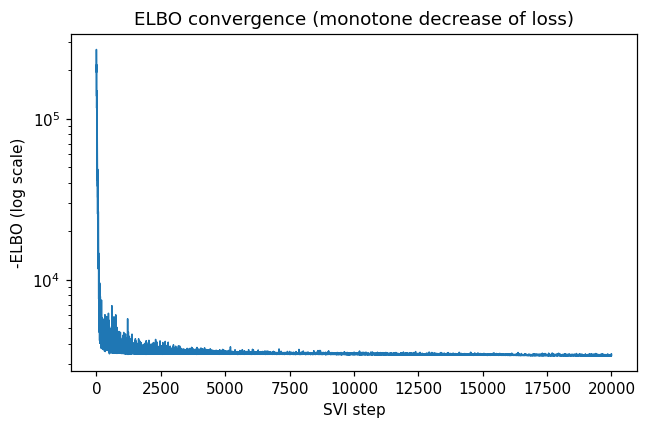

In [9]:
plt.figure(figsize=(6,4))
plt.plot(res.losses, lw=1)
plt.yscale("log"); plt.xlabel("SVI step"); plt.ylabel("-ELBO (log scale)")
plt.title("ELBO convergence (monotone decrease of loss)")
plt.tight_layout(); plt.savefig("fig_elbo.png", bbox_inches="tight"); plt.show()

In [10]:
def predict_svi(guide, params, prior_sd, seed=1):
    pred = Predictive(bnn, guide=guide, params=params, num_samples=1000)
    s = pred(jax.random.PRNGKey(seed), jnp.array(xg), prior_sd=prior_sd)
    return np.asarray(s["mu"]), np.asarray(s["y"])

mu_s, y_s = predict_svi(guide, res.params, 1.0)
bnn_mu   = unz_y(mu_s.mean(0))
bnn_mu_lo, bnn_mu_hi = unz_y(np.percentile(mu_s, [2.5, 97.5], axis=0))   # 평균함수 신용구간
bnn_pp_lo, bnn_pp_hi = unz_y(np.percentile(y_s,  [2.5, 97.5], axis=0))   # 예측분포(잡음 포함)

s_te = Predictive(bnn, guide=guide, params=res.params, num_samples=1000)(
    jax.random.PRNGKey(2), jnp.array(x_te), prior_sd=1.0)
bnn_rmse = np.sqrt(np.mean((unz_y(np.asarray(s_te["mu"]).mean(0)) - unz_y(y_te)) ** 2))
print(f"[BNN SVI] test RMSE = {bnn_rmse:.2f}")

# 핵심: 신용구간 폭이 희박 구간에서 넓어지는지 확인
band = bnn_mu_hi - bnn_mu_lo
print("\n연령별 95% 평균함수 신용구간 폭:")
for a in [20, 30, 42, 60, 78]:
    j = int(np.argmin(np.abs(age_grid - a)))
    print(f"  age~{a:>2d}:  mean={bnn_mu[j]:6.1f}   band width={band[j]:5.1f}")

[BNN SVI] test RMSE = 40.03

연령별 95% 평균함수 신용구간 폭:
  age~20:  mean=  72.0   band width= 20.1
  age~30:  mean= 104.1   band width= 16.5
  age~42:  mean= 119.6   band width= 13.7
  age~60:  mean= 117.4   band width= 18.7
  age~78:  mean= 110.5   band width= 24.6


### 4.4 NUTS(HMC) 검증 및 수렴 진단

변분근사(SVI)가 사후분포를 잘 근사했는지 확인하기 위해 NUTS로 동일 모형을 샘플링한다.
**유의점:** BNN의 가중치는 부호·치환 대칭으로 인해 **비식별(non-identifiable)** 이므로
가중치 자체의 $\hat R$ 은 의미가 없다. 따라서 식별 가능한 양인 **잡음 $\sigma$** 와
**함수값 $f(x)$**(특정 연령에서의 예측)에 대해 수렴을 진단한다(3·10강).

In [11]:
mcmc = MCMC(NUTS(bnn), num_warmup=500, num_samples=500,
            num_chains=2, progress_bar=False)
mcmc.run(jax.random.PRNGKey(0), jnp.array(x_tr), jnp.array(y_tr), prior_sd=1.0)

post = mcmc.get_samples()
gc = mcmc.get_samples(group_by_chain=True)
sig_summary = diag.summary(gc, prob=0.9)["sigma"]
print(f"sigma:  mean={float(post['sigma'].mean()):.3f}  "
      f"r_hat={sig_summary['r_hat']:.3f}  n_eff={sig_summary['n_eff']:.0f}")

C:\Users\barkl\AppData\Local\Temp\claude\ipykernel_19168\2500833956.py:1: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(NUTS(bnn), num_warmup=500, num_samples=500,


sigma:  mean=0.956  r_hat=1.001  n_eff=1012


In [12]:
# 함수공간 진단: 대표 연령에서 f(x)의 r_hat / n_eff
def f_at( chain_w1, chain_b1, chain_w2, chain_b2, xv):
    z = np.tanh(xv * chain_w1[..., 0, :] + chain_b1)           # (chain, draw, H)
    return (z * chain_w2[..., 0]).sum(-1) + chain_b2            # (chain, draw)

print("연령별 함수값 f(age) 수렴 진단 (NUTS):")
for a in [20, 42, 78]:
    xv = (a - age_m) / age_s
    fa = f_at(np.asarray(gc["w1"]), np.asarray(gc["b1"]),
              np.asarray(gc["w2"]), np.asarray(gc["b2"]), xv)   # (chain, draw)
    rhat = diag.gelman_rubin(fa); neff = diag.effective_sample_size(fa)
    print(f"  age~{a:>2d}:  f mean(wage)={unz_y(fa.mean()):6.1f}  "
          f"r_hat={float(rhat):.3f}  n_eff={float(neff):.0f}")

# NUTS 사후예측 밴드(SVI와 비교용)
predm = Predictive(bnn, posterior_samples=post)(
    jax.random.PRNGKey(5), jnp.array(xg), prior_sd=1.0)
nuts_mu = unz_y(np.asarray(predm["mu"]).mean(0))
nuts_lo, nuts_hi = unz_y(np.percentile(np.asarray(predm["mu"]), [2.5,97.5], axis=0))

연령별 함수값 f(age) 수렴 진단 (NUTS):
  age~20:  f mean(wage)=  69.5  r_hat=0.999  n_eff=919
  age~42:  f mean(wage)= 119.3  r_hat=1.000  n_eff=953
  age~78:  f mean(wage)= 100.4  r_hat=0.999  n_eff=1001


## 5. 결과 시각화

### 5.1 세 모형 비교와 BNN의 불확실성

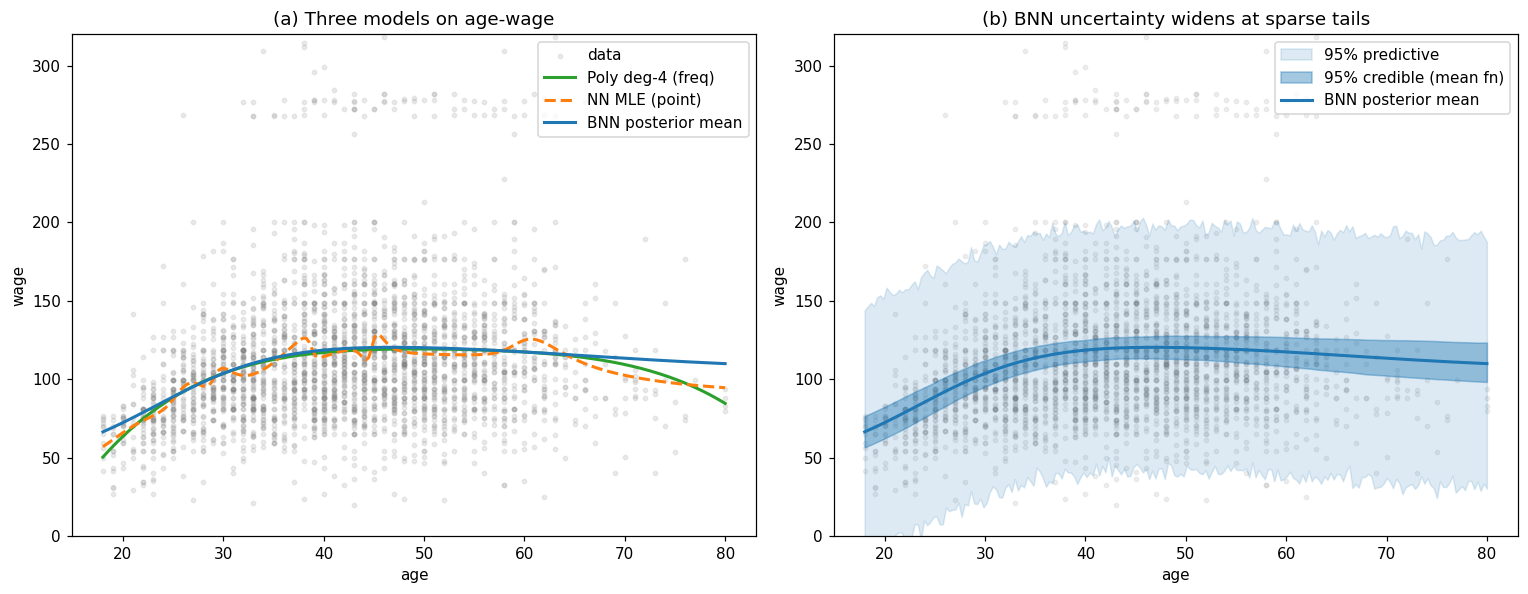

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

ax[0].scatter(age, wage, s=8, alpha=0.15, color="gray", label="data")
ax[0].plot(age_grid, poly_mean, color="tab:green", lw=2, label="Poly deg-4 (freq)")
ax[0].plot(age_grid, nn_grid,  color="tab:orange", lw=2, ls="--", label="NN MLE (point)")
ax[0].plot(age_grid, bnn_mu,   color="tab:blue", lw=2, label="BNN posterior mean")
ax[0].set_title("(a) Three models on age-wage"); ax[0].set_xlabel("age")
ax[0].set_ylabel("wage"); ax[0].set_ylim(0, 320); ax[0].legend()

ax[1].scatter(age, wage, s=8, alpha=0.12, color="gray")
ax[1].fill_between(age_grid, bnn_pp_lo, bnn_pp_hi, color="tab:blue", alpha=0.15,
                   label="95% predictive")
ax[1].fill_between(age_grid, bnn_mu_lo, bnn_mu_hi, color="tab:blue", alpha=0.40,
                   label="95% credible (mean fn)")
ax[1].plot(age_grid, bnn_mu, color="tab:blue", lw=2, label="BNN posterior mean")
ax[1].set_title("(b) BNN uncertainty widens at sparse tails")
ax[1].set_xlabel("age"); ax[1].set_ylabel("wage"); ax[1].set_ylim(0, 320); ax[1].legend()
plt.tight_layout(); plt.savefig("fig_main.png", bbox_inches="tight"); plt.show()

### 5.2 SVI와 NUTS의 평균함수 비교
두 추론기의 평균함수와 신용구간이 거의 일치하면, 계산이 빠른 SVI 근사가
신뢰할 만함을 의미한다.

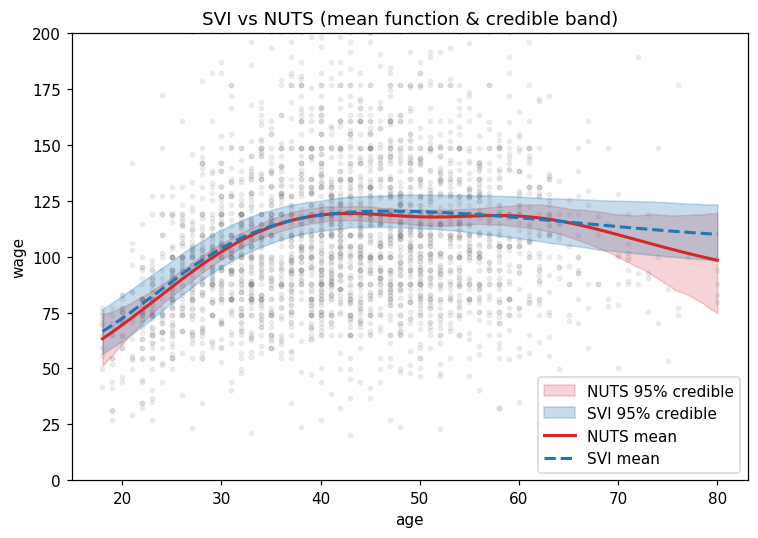

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(age, wage, s=8, alpha=0.12, color="gray")
plt.fill_between(age_grid, nuts_lo, nuts_hi, color="tab:red", alpha=0.20, label="NUTS 95% credible")
plt.fill_between(age_grid, bnn_mu_lo, bnn_mu_hi, color="tab:blue", alpha=0.25, label="SVI 95% credible")
plt.plot(age_grid, nuts_mu, color="tab:red", lw=2, label="NUTS mean")
plt.plot(age_grid, bnn_mu, color="tab:blue", lw=2, ls="--", label="SVI mean")
plt.title("SVI vs NUTS (mean function & credible band)")
plt.xlabel("age"); plt.ylabel("wage"); plt.ylim(0, 200); plt.legend()
plt.tight_layout(); plt.savefig("fig_svi_vs_nuts.png", bbox_inches="tight"); plt.show()

### 5.3 사전분포(prior) 수축 강도 민감도
가중치 사전 표준편차 $s$ 를 작게 하면(강한 수축) 함수가 더 매끄럽고 단순해지며,
크게 하면 데이터에 더 유연하게 적합한다. 이는 12강의 수축 사전분포/규제 효과에 해당한다.

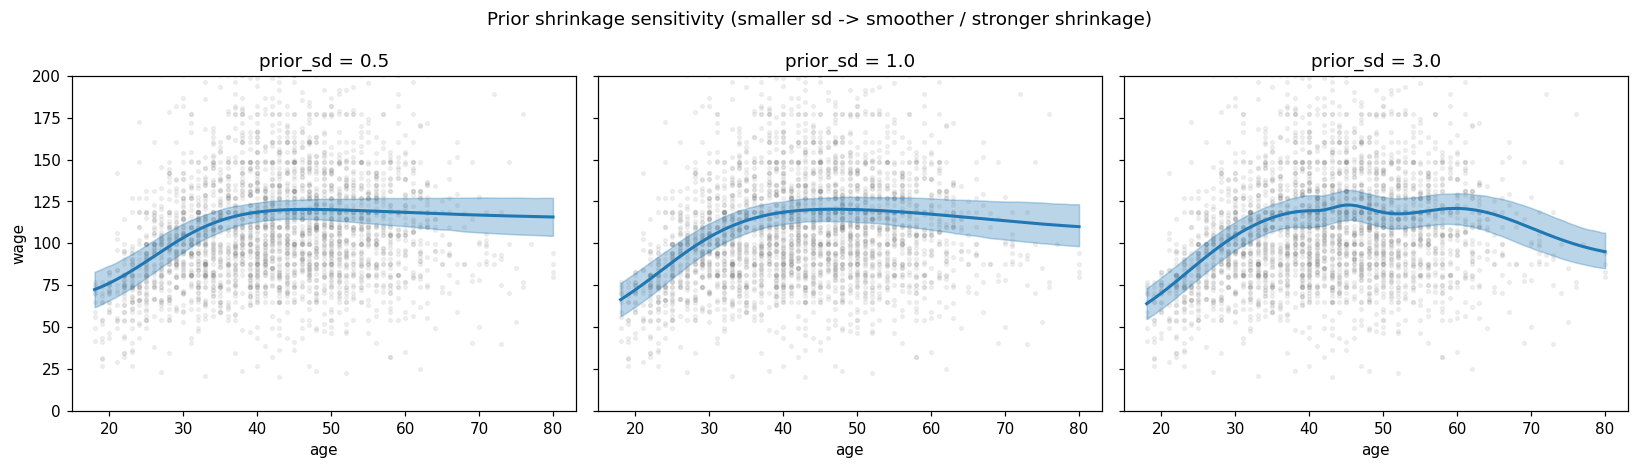

In [15]:
curves = {}
for s_sd in [0.5, 1.0, 3.0]:
    g_, r_ = fit_svi(prior_sd=s_sd)
    mu_, _ = predict_svi(g_, r_.params, s_sd)
    curves[s_sd] = (unz_y(mu_.mean(0)),
                    *[unz_y(q) for q in np.percentile(mu_, [2.5, 97.5], axis=0)])

fig, ax = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
for k, s_sd in enumerate([0.5, 1.0, 3.0]):
    m, lo, hi = curves[s_sd]
    ax[k].scatter(age, wage, s=6, alpha=0.10, color="gray")
    ax[k].fill_between(age_grid, lo, hi, color="tab:blue", alpha=0.30)
    ax[k].plot(age_grid, m, color="tab:blue", lw=2)
    ax[k].set_title(f"prior_sd = {s_sd}"); ax[k].set_xlabel("age"); ax[k].set_ylim(0, 200)
ax[0].set_ylabel("wage")
plt.suptitle("Prior shrinkage sensitivity (smaller sd -> smoother / stronger shrinkage)")
plt.tight_layout(); plt.savefig("fig_prior.png", bbox_inches="tight"); plt.show()

## 6. 비교 및 논의

In [16]:
summary = pd.DataFrame({
    "model": ["Poly deg-4 (freq)", "NN (MLE)", "BNN (SVI)"],
    "test RMSE": [round(poly_rmse,2), round(nn_rmse,2), round(bnn_rmse,2)],
    "uncertainty": ["CI(평균함수만)", "없음", "신용구간+예측구간"],
    "nonlinear": ["O(차수 고정)", "O", "O"],
})
summary

,model,test RMSE,uncertainty,nonlinear
0,Poly deg-4 (freq),39.98,CI(평균함수만),O(차수 고정)
1,NN (MLE),40.32,없음,O
2,BNN (SVI),40.03,신용구간+예측구간,O


### 논의
- **예측 정확도(RMSE)는 세 모형이 비슷하다.** 연령 단독으로 설명되는 임금 변동이
  제한적이고(임금의 이질성·이봉구조), 세 모형 모두 동일한 역U자 평균함수를 잡아내기
  때문이다. 즉 이 사례에서 BNN의 가치는 *점예측 정확도*가 아니라 **불확실성의 표현**에 있다.
- **불확실성의 구조적 차이.** 다항회귀의 신뢰구간은 모형 구조(4차)를 참으로 가정한
  좁은 구간이고, NN(MLE)은 불확실성 자체가 없다. 반면 BNN은 데이터가 희박한
  청년·고령 구간에서 신용구간을 **자동으로 넓혀**, 외삽 위험을 정직하게 드러낸다(§4.3 표).
- **SVI 근사의 타당성.** SVI와 NUTS의 평균함수·신용구간이 거의 일치(§5.2)하여,
  계산이 빠른 변분근사가 본 문제에서 신뢰할 만함을 확인했다.
- **사전분포의 역할.** prior 수축이 강하면(작은 $s$) 더 단순·매끄러운 함수가,
  약하면 더 유연한 함수가 얻어진다(§5.3) — 규제(regularization)의 베이지안적 해석.
- **한계와 확장.** 임금의 이봉구조는 단일 정규 가능도로 포착되지 않는다. (i) 학력·성별 등
  공변량을 입력에 추가하거나, (ii) 분산을 입력의 함수로 두는 **이분산(heteroscedastic)**
  가능도, (iii) 혼합밀도(mixture density) 출력으로 확장하면 개선될 수 있다.


## 7. 결론

연령–임금이라는 비선형 회귀 문제에서 다항회귀·일반 신경망·베이지안 신경망을 비교한 결과,
세 모형의 평균 예측은 유사하지만 **불확실성의 표현에서 결정적 차이**가 드러났다.
BNN은 가중치를 분포로 두고 SVI로 사후분포를 근사함으로써, 데이터가 풍부한 중년층에서는
좁고 희박한 청년·고령층에서는 넓은 **신용구간**을 제공한다. 이는 예측의 신뢰도를
정량화해야 하는 실무(정책·의사결정)에서 점추정만 제공하는 전통적 신경망보다 베이지안
접근이 갖는 본질적 이점이다. NUTS 검증과 prior 민감도 분석은 결과의 강건성과
모형 설정의 의미를 뒷받침한다.
